In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import kagglehub

In [5]:
# Download dataset using kagglehub
path = kagglehub.dataset_download("andrewmvd/ct-low-dose-reconstruction")

# Correct folder inside dataset
data_root = path + "/Preprocessed_512x512/512"

print("Dataset Path:", data_root)

# Verify structure
print(os.listdir(data_root))

100%|██████████| 18.3G/18.3G [03:15<00:00, 101MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/andrewmvd/ct-low-dose-reconstruction/versions/2/Preprocessed_512x512/512
['Quarter Dose', 'Full Dose']


In [15]:
ld_files, nd_files = collect_image_paths(data_root)

(train_ld, train_nd), (test_ld, test_nd) = split_data(ld_files, nd_files)

In [16]:
test_ld = test_ld[:50]
test_nd = test_nd[:50]

In [17]:
test_dataset = CTDataset(test_ld, test_nd, train=False)
test_loader = DataLoader(test_dataset, batch_size=1)

In [7]:
class CTDataset(Dataset):
    def __init__(self, ldct_list, ndct_list, train=True):
        self.ldct_list = ldct_list
        self.ndct_list = ndct_list
        self.train = train

    def __len__(self):
        return len(self.ldct_list)

    def __getitem__(self, idx):
        ld_img = Image.open(self.ldct_list[idx]).convert('L')
        nd_img = Image.open(self.ndct_list[idx]).convert('L')

        ld = np.array(ld_img).astype(np.float32) / 255.0
        nd = np.array(nd_img).astype(np.float32) / 255.0

        if self.train:
            h, w = ld.shape
            patch_size = 64
            top = np.random.randint(0, h - patch_size)
            left = np.random.randint(0, w - patch_size)

            ld = ld[top:top+patch_size, left:left+patch_size]
            nd = nd[top:top+patch_size, left:left+patch_size]

        return torch.from_numpy(ld).unsqueeze(0), torch.from_numpy(nd).unsqueeze(0)

In [8]:
def collect_image_paths(root_dir):
    ld_root = os.path.join(root_dir, "Quarter Dose/1mm/Soft Kernel (B30)")
    nd_root = os.path.join(root_dir, "Full Dose/1mm/Soft Kernel (B30)")

    ld_files, nd_files = [], []

    for patient in sorted(os.listdir(ld_root)):
        ld_p = os.path.join(ld_root, patient)
        nd_p = os.path.join(nd_root, patient)

        for ld_img, nd_img in zip(sorted(os.listdir(ld_p)), sorted(os.listdir(nd_p))):
            ld_files.append(os.path.join(ld_p, ld_img))
            nd_files.append(os.path.join(nd_p, nd_img))

    return ld_files, nd_files

In [9]:
def split_data(ld_files, nd_files, split=0.9):
    n = int(len(ld_files) * split)
    return (ld_files[:n], nd_files[:n]), (ld_files[n:], nd_files[n:])

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        b = self.bottleneck(self.pool3(d3))

        u3 = self.up3(b)
        u3 = self.conv3(torch.cat([u3, d3], dim=1))

        u2 = self.up2(u3)
        u2 = self.conv2(torch.cat([u2, d2], dim=1))

        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, d1], dim=1))

        return self.final(u1)

In [11]:
def train_model(model, loader, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for ld, nd in loader:
            ld, nd = ld.to(device), nd.to(device)

            optimizer.zero_grad()
            output = model(ld)
            loss = criterion(output, nd)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}: Loss {total_loss/len(loader):.4f}")

    return model

In [12]:
def evaluate(model, loader):
    device = next(model.parameters()).device
    model.eval()

    psnr_list, ssim_list = [], []

    with torch.no_grad():
        for ld, nd in loader:
            ld = ld.to(device)
            pred = model(ld).cpu().squeeze().numpy()
            gt = nd.squeeze().numpy()

            psnr_list.append(psnr(gt, pred, data_range=1.0))
            ssim_list.append(ssim(gt, pred, data_range=1.0))

    print("PSNR:", np.mean(psnr_list))
    print("SSIM:", np.mean(ssim_list))

In [13]:
def show_results(model, loader):
    device = next(model.parameters()).device
    model.eval()

    ld, nd = next(iter(loader))
    ld = ld.to(device)

    with torch.no_grad():
        pred = model(ld)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(ld.cpu().squeeze(), cmap='gray')
    plt.title("LDCT")

    plt.subplot(1,3,2)
    plt.imshow(pred.cpu().squeeze(), cmap='gray')
    plt.title("Denoised")

    plt.subplot(1,3,3)
    plt.imshow(nd.squeeze(), cmap='gray')
    plt.title("NDCT")

    plt.show()

Saving unet_model.pth to unet_model (2).pth
Model Loaded Successfully
PSNR: 40.897850544764836
SSIM: 0.9550893982063936


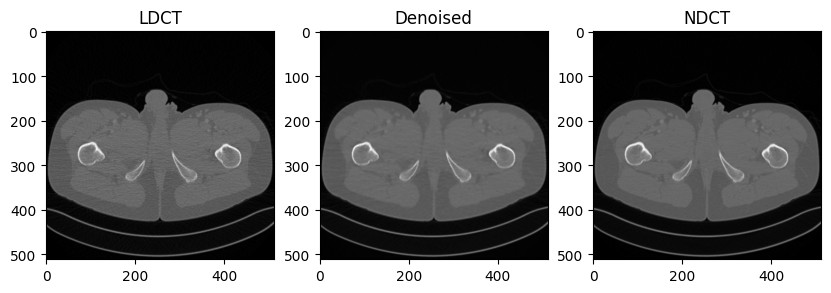

In [18]:
# Upload model
from google.colab import files
uploaded = files.upload()

# Load model
model = UNet()
model.load_state_dict(torch.load("unet_model.pth"))
model.eval()

print("Model Loaded Successfully")

# Reduce dataset for speed
test_ld = test_ld[:50]
test_nd = test_nd[:50]

# Reload test loader
test_dataset = CTDataset(test_ld, test_nd, train=False)
test_loader = DataLoader(test_dataset, batch_size=1)

# Evaluate
evaluate(model, test_loader)

# Show result
show_results(model, test_loader)

In [19]:
torch.save(model.state_dict(), "unet_model.pth")